In [1]:
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from src.diffeomorphisms.vector.r3.tree import TreeVectorDiffeomorphism
from src.manifolds.euclidean.vector.pullback.hyperbolic.tree import TreeHyperbolicdPullbackVectorEuclidean

# set random seed for reproducibility
torch.manual_seed(31)

Pairwise distance matrix:
tensor([[0.0000, 2.8284, 2.8284, 2.8284],
        [2.8284, 0.0000, 2.8284, 2.8284],
        [2.8284, 2.8284, 0.0000, 2.8284],
        [2.8284, 2.8284, 2.8284, 0.0000]])


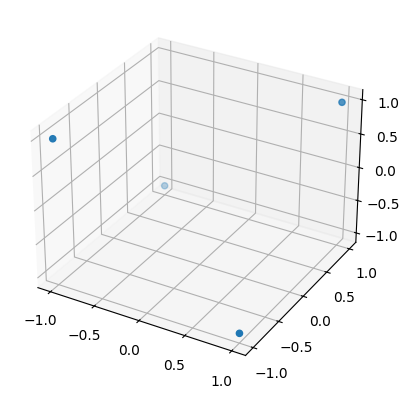

In [2]:
# construct data set as the four corners of a tetrahedron in R3
data = torch.tensor([[1.0, 1.0, 1.0],
                     [1.0, -1.0, -1.0],
                     [-1.0, 1.0, -1.0],
                     [-1.0, -1.0, 1.0]])

# compute pairwise distance matrix
dist_matrix = torch.cdist(data, data, p=2)
print("Pairwise distance matrix:")
print(dist_matrix)

# plot the points in 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0], data[:, 1], data[:, 2])
plt.show()

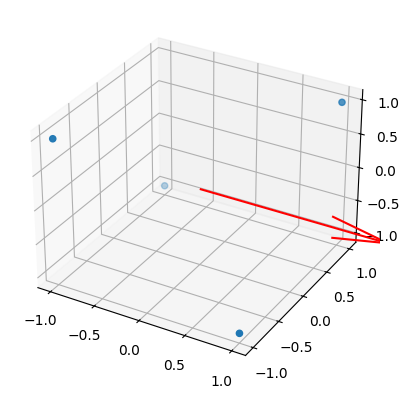

In [3]:
b = data.mean(dim=0)
v = (data[0] + data[1] - data[2] - data[3])/2

# plot quiver at b with direction v
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.quiver(b[0], b[1], b[2], v[0], v[1], v[2], color='r')
ax.scatter(data[:, 0], data[:, 1], data[:, 2])
plt.show()

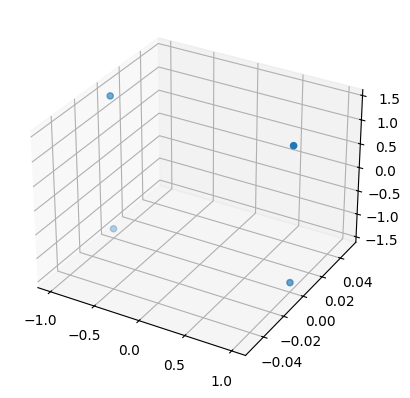

In [4]:
# rotate the data around the x-axis by an angle that is a function  the x-coordinate
angle = data[:, 0] * (3.141592653589793 / 4)  # angle varies from -pi/4 to pi/4
Rx_var = torch.zeros((4, 3, 3))
for i in range(4):
    Rx_var[i] = torch.tensor([[1, 0, 0],
                              [0, torch.cos(angle[i]), -torch.sin(angle[i])],
                              [0, torch.sin(angle[i]), torch.cos(angle[i])]])
data_rotated = torch.zeros_like(data)
for i in range(4):
    data_rotated[i] = Rx_var[i] @ (data[i] - b) + b

# plot rotated data
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data_rotated[:, 0], data_rotated[:, 1], data_rotated[:, 2])
plt.show()

tensor([[ 1.,  0.,  0.],
        [ 0.,  0., -1.],
        [ 0.,  1.,  0.]])
tensor([[ 1., -1.,  0.],
        [ 1.,  1.,  0.],
        [-1.,  1.,  0.],
        [-1., -1.,  0.]])
tensor([0., 0., 0., 0.])


/var/folders/7n/h6r1srp97v78dhwb2rxn_k5m0000gn/T/ipykernel_6944/3795611076.py:5: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Cross.cpp:67.)
  v = torch.cross(a, b)


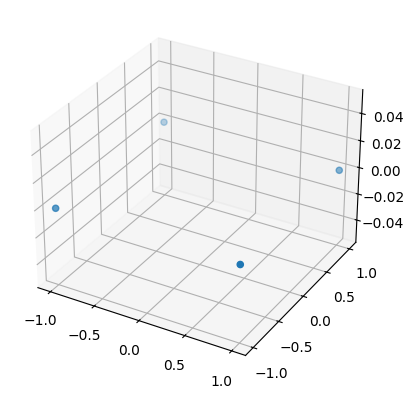

In [5]:
# Subtract the mean (centroid)
def rotation_matrix_from_vectors(a, b):
    a = a / torch.norm(a)
    b = b / torch.norm(b)
    v = torch.cross(a, b)
    c = torch.dot(a, b)
    s = torch.norm(v)
    K = torch.tensor([[0, -v[2], v[1]],
                      [v[2], 0, -v[0]],
                      [-v[1], v[0], 0]])
    R = torch.eye(3) + K + K @ K * ((1 - c) / (s ** 2))
    return R

centroid = torch.mean(data, dim=0)
data_centered = data_rotated - centroid

# SVD/PCA for best-fit plane
U, S, V = torch.svd(data_centered)
# V[:, -1] is the direction orthogonal to the best-fit plane (normal vector)
normal_vector = V[:, -1]

# Now rotate so normal_vector aligns with z-axis
z_axis = torch.tensor([0., 0., 1.])
T_plane = rotation_matrix_from_vectors(normal_vector, z_axis)

print(T_plane)

# Apply the transformation
data_projected = data_centered @ T_plane.T

# rescale y-axis to preserve distances
scale_factor = torch.sqrt(torch.tensor(2.0))
data_projected[:, 1] /= scale_factor

# Now, all z-coordinates should be nearly zero
print(data_projected)
print(data_projected[:, 2])
# plot final data
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data_projected[:, 0], data_projected[:, 1], data_projected[:, 2])
plt.show()

Transformed data:
tensor([[ 1., -1.,  0.],
        [ 1.,  1.,  0.],
        [-1.,  1.,  0.],
        [-1., -1.,  0.]])


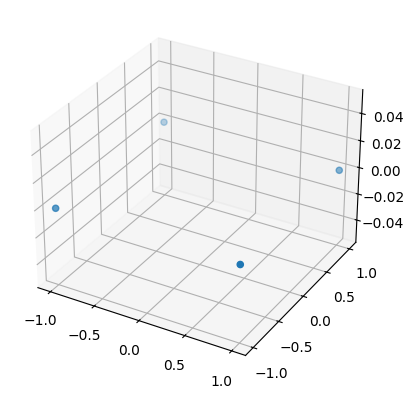

In [6]:
diffeo = TreeVectorDiffeomorphism()

phi_data = diffeo.forward(data)

print("Transformed data:")
print(phi_data)

plt.figure()
ax = plt.axes(projection='3d')
ax.scatter(phi_data[:, 0], phi_data[:, 1], phi_data[:, 2])
plt.show()

Inverse transformed data:
tensor([[ 1.0000,  1.0000,  1.0000],
        [ 1.0000, -1.0000, -1.0000],
        [-1.0000,  1.0000, -1.0000],
        [-1.0000, -1.0000,  1.0000]])
Difference between original and inverse transformed data:
tensor([[ 0.0000e+00,  5.9605e-08,  5.9605e-08],
        [ 0.0000e+00, -5.9605e-08, -5.9605e-08],
        [ 0.0000e+00,  5.9605e-08, -5.9605e-08],
        [ 0.0000e+00, -5.9605e-08,  5.9605e-08]])


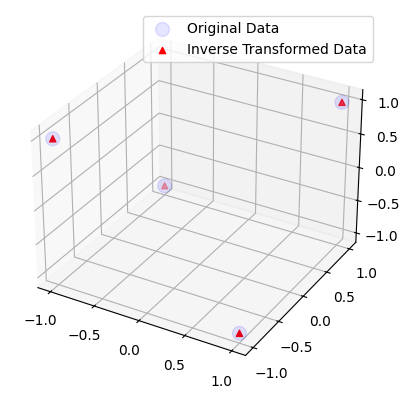

In [7]:
phi_inv_phi_data = diffeo.inverse(phi_data)

print("Inverse transformed data:")
print(phi_inv_phi_data)
print("Difference between original and inverse transformed data:")
print(data - phi_inv_phi_data)

# plot data and inverse transformed data
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0], data[:, 1], data[:, 2], color='b', label='Original Data', alpha=0.1, s=100)
ax.scatter(phi_inv_phi_data[:, 0], phi_inv_phi_data[:, 1], phi_inv_phi_data[:, 2], color='r', label='Inverse Transformed Data', marker='^')
ax.legend()
plt.show()

In [8]:
manifold = TreeHyperbolicdPullbackVectorEuclidean()

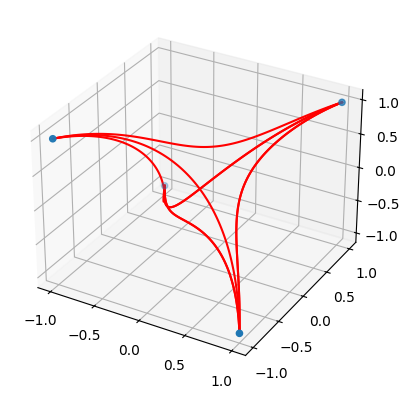

In [11]:
# compute geodesics between all pairs of points
t = torch.linspace(0, 1, steps=100)
geodesics = manifold.geodesic(data[None], data[None], t)

# plot geodesics
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
for i in range(geodesics.shape[1]):
    for j in range(geodesics.shape[2]-1):
        ax.plot(geodesics[0, i, j, :, 0].numpy(), geodesics[0, i, j, :, 1].numpy(), geodesics[0, i, j, :, 2].numpy(), 'r-')
ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), data[:, 2].numpy())
plt.show()